# Task B-2: Prometheus Model Evaluation

## 1. Project Context
This notebook focuses on evaluating the already fine-tuned **YOLOv10s** model for gym occupancy detection.

## 2. Model Architecture & Strategy
- **Architecture**: **YOLOv10s** (Small) for balanced inference speed and accuracy.
- **Strategy**: **Transfer Learning** with layer freezing (first 10 layers frozen).

## 3. Performance Targets
As defined in our project roadmap:
- **Primary Metric**: mAP@0.5 >= **0.85**
- **Operational Metric**: State Accuracy >= **95%** for owner dashboard reporting.

---

### [Reference] Previous Training Configuration
The model was trained using the following configuration (already completed):
```python
# model.train(
#     data='model/data/prometheus_data.yml',
#     epochs=50,
#     ...
# )
```

## 4. Model Evaluation
We load the **existing** `best.pt` weights and run validation on the **final_dataset**.

In [ ]:
from ultralytics import YOLO
import os
import yaml
import cv2
import matplotlib.pyplot as plt

# 1. Find Project Root
cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    ROOT_DIR = os.path.abspath(os.path.join(cwd, '..'))
else:
    ROOT_DIR = cwd

print(f"Project Root: {ROOT_DIR}")

# 2. Prepare Absolute Path YAML (Fixes YOLO FileNotFoundError)
dataset_path = os.path.join(ROOT_DIR, 'model/data/final_dataset')
if not os.path.exists(dataset_path):
    print(f"⚠️ final_dataset not found, falling back to test_frames")
    dataset_path = os.path.join(ROOT_DIR, 'model/data/test_frames')

data_config = {
    'path': dataset_path,
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'person',
        1: 'gym-machine'
    }
}

temp_yaml_path = os.path.join(ROOT_DIR, 'model/data/prometheus_eval.yml')
with open(temp_yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print(f"Created evaluation config with absolute path: {temp_yaml_path}")

# 3. Load the EXISTING best model weights
best_model_path = os.path.join(ROOT_DIR, 'runs/detect/prometheus_runs/baseline_model/weights/best.pt')

if os.path.exists(best_model_path):
    model = YOLO(best_model_path)
    print("✅ Successfully loaded fine-tuned model weights.")
    
    # 4. Run validation
    print("Running validation evaluation...")
    # Use the absolute path YAML we just created
    metrics = model.val(data=temp_yaml_path)
    
    # 5. Display key results
    map50 = metrics.results_dict['metrics/mAP50(B)']
    print(f"\n--- Performance Summary ---")
    print(f"Dataset: {os.path.basename(dataset_path)}")
    print(f"Mean Average Precision (mAP@0.5): {map50:.4f}")
    
    if map50 >= 0.85:
        print("🎯 Status: Performance Target Met!")
    else:
        print("⚠️ Status: Performance Target Not Met.")
else:
    print(f"❌ Error: {best_model_path} not found.")

Project Root: c:\Users\Phasit\Desktop\Prometheus\Prometheus
Created evaluation config with absolute path: c:\Users\Phasit\Desktop\Prometheus\Prometheus\model/data/prometheus_eval.yml
✅ Successfully loaded fine-tuned model weights.
Running validation evaluation...
Ultralytics 8.4.48  Python-3.10.6 torch-2.11.0+cpu CPU (13th Gen Intel Core i5-13500HX)
YOLOv10s summary (fused): 106 layers, 7,218,774 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 37.03.0 MB/s, size: 275.5 KB)
val: Scanning C:\Users\Phasit\Desktop\Prometheus\Prometheus\model\data\final_dataset\labels\val... 97 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 97/97 454.5it/s 0.2s0.0s
val: New cache created: C:\Users\Phasit\Desktop\Prometheus\Prometheus\model\data\final_dataset\labels\val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.0s/it 7.1s1.3ss
                   all         97       1245      0.596      0.5

## 5. Visualizing Existing Results
YOLO automatically saves performance plots during training. We can display them here for the final report.

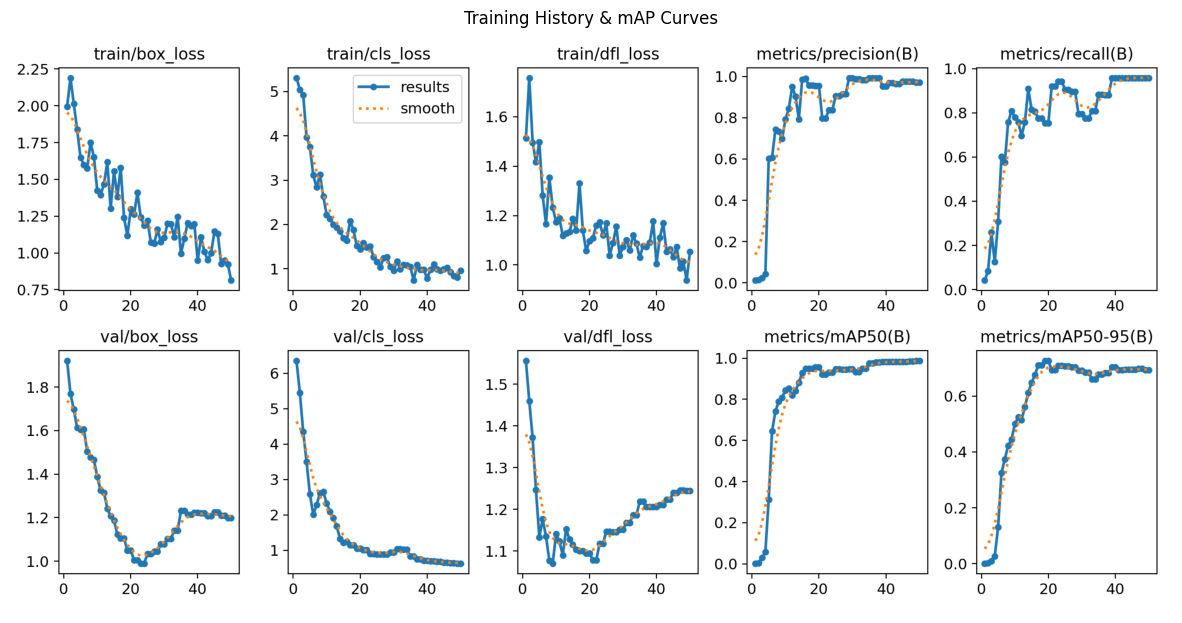

In [ ]:
results_img = os.path.join(ROOT_DIR, 'runs/detect/prometheus_runs/baseline_model/results.png')
if os.path.exists(results_img):
    img = cv2.imread(results_img)
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Training History & mAP Curves")
    plt.axis('off')
    plt.show()
else:
    print("Results plot not found.")